# Foundation Models for Acoustic Scene Analysis

**Goal:** given a short audio clip, decide which *acoustic scene* it was recorded in:

| Our label | What it sounds like |
|-----------|---------------------|
| `Restaurant` | cafe / restaurant chatter, cutlery |
| `Street` | city traffic, people outside |
| `Office` | keyboards, quiet talking, AC hum |
| `Car` | engine, road noise from inside a car |

**The idea — use audio *foundation models* as feature extractors.**

Instead of training an audio network from scratch, we take three models that were **pre-trained on
huge amounts of audio** and use them *frozen* to turn each clip into a single vector (an
*embedding*). Then we train a tiny classifier (logistic regression) on top. This is called a
**linear probe**.

```
audio clip --> [ frozen foundation model ] --> embedding (768 numbers) --> [ logistic regression ] --> scene
                 (BEATs / WavLM / HuBERT)                                       trained by us
```

**The three models we compare** (all pulled from the Hugging Face Hub):

| Model | What it is | Hugging Face source |
|-------|------------|---------------------|
| **BEATs** | Audio pre-training with acoustic tokenizers (Microsoft). Strong on general *sounds/scenes*. | code: `microsoft/unilm`, weights: `lpepino/beats_ckpts` |
| **WavLM** | Speech model (Microsoft) that also models background / overlapping noise. | `microsoft/wavlm-base-plus` |
| **HuBERT** | Self-supervised speech model (Meta). | `facebook/hubert-base-ls960` |

Run the cells top to bottom.

## Step 1 — Install dependencies

We need `transformers` (for WavLM & HuBERT), `torchaudio` (BEATs uses it for its mel features),
`librosa` + `soundfile` (load/resample audio), `scikit-learn` (the linear probe) and
`huggingface_hub` (download models + dataset).

If a package is already installed, pip just skips it.

In [1]:
%pip install -q "transformers>=4.40" torch torchaudio librosa soundfile scikit-learn huggingface_hub matplotlib pandas


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.

## Step 2 — Configuration

All the knobs in one place.

- `TARGET_SCENES` maps **our 4 labels** to the matching class names in the public dataset
  (TUT Acoustic Scenes 2017). The dataset has no exact "street" class, so we use `city_center`.
- `N_PER_CLASS` is how many clips per scene to download. Start small (it keeps the download and the
  CPU work short); raise it later for better accuracy.

In [2]:
import os
from pathlib import Path
import torch

# Keep the notebook output clean: turn off Hugging Face's per-file download
# progress bars (otherwise each of the ~100 downloads prints a widget that the
# Jupyter frontend can't render -> the "Could not render ... widget-view" lines).
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
from huggingface_hub.utils import disable_progress_bars
disable_progress_bars()

# Hide harmless library deprecation notices (BEATs uses the old weight_norm API,
# WavLM warns about an attention-mask detail) so the output stays readable.
import warnings
warnings.filterwarnings("ignore", message=".*weight_norm.*")
warnings.filterwarnings("ignore", message=".*key_padding_mask.*")
warnings.filterwarnings("ignore", category=FutureWarning, module="torch")

# Quiet the Hub's "unauthenticated requests" notice (downloads still work fine).
from huggingface_hub.utils import logging as hf_logging
hf_logging.set_verbosity_error()

# Our 4 scenes  ->  the matching class name in the TUT Acoustic Scenes 2017 dataset
TARGET_SCENES = {
    "Restaurant": "cafe/restaurant",
    "Street":     "city_center",
    "Office":     "office",
    "Car":        "car",
}

SR            = 16000   # all three models expect 16 kHz mono audio
CLIP_SECONDS  = 10      # use at most this many seconds per clip
N_PER_CLASS   = 25      # clips per scene to download (bump up for higher accuracy)
TEST_FRACTION = 0.25    # held-out test split
SEED          = 42

DATA_DIR  = Path("data");       DATA_DIR.mkdir(exist_ok=True)
CACHE_DIR = Path("embeddings"); CACHE_DIR.mkdir(exist_ok=True)

# Use a GPU automatically if one happens to be available, otherwise CPU.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Scenes :", list(TARGET_SCENES))
print("Device :", DEVICE)

Scenes : ['Restaurant', 'Street', 'Office', 'Car']
Device : cpu


## Step 3 — Get a small labelled dataset

We use **TUT Acoustic Scenes 2017** (mirrored on the Hub at `MahiA/TUT2017`). It contains 10-second
recordings of real scenes, including `cafe/restaurant`, `car`, `office` and `city_center` — exactly
what we need.

The full dataset is large (~12 GB), so we **only download a handful of files per scene**: we read
the label CSV first, pick `N_PER_CLASS` files for each of our 4 scenes, and download just those.

> **Want to use your own recordings instead?** Put `.wav` files in folders named after the labels
> (`data/mine/Restaurant/*.wav`, `data/mine/Street/*.wav`, ...) and use the `load_my_folder()`
> helper provided after the next cell.

In [3]:
import pandas as pd
from huggingface_hub import hf_hub_download

DATASET_REPO = "MahiA/TUT2017"

def get_dataset_subset(target_scenes=TARGET_SCENES, n_per_class=N_PER_CLASS, seed=SEED):
    """Download a few clips per scene and return a DataFrame: columns [filepath, label]."""
    # 1) the label file (tiny) lists every clip and its scene class
    csv_path = hf_hub_download(DATASET_REPO, "csv_files/train.csv", repo_type="dataset")
    catalog = pd.read_csv(csv_path)  # columns: path, classname

    rows = []
    for our_label, tut_class in target_scenes.items():
        clips = catalog[catalog["classname"] == tut_class]
        clips = clips.sample(min(n_per_class, len(clips)), random_state=seed)
        print(f"  {our_label:11s} <- '{tut_class}'  ({len(clips)} clips)")
        for rel_path in clips["path"]:
            # 2) download just this one audio file from the dataset repo
            local = hf_hub_download(DATASET_REPO, rel_path, repo_type="dataset")
            rows.append({"filepath": local, "label": our_label})
    return pd.DataFrame(rows).sample(frac=1, random_state=seed).reset_index(drop=True)

print("Downloading clips (first run takes a minute)...")
data = get_dataset_subset()
print(f"\nTotal clips: {len(data)}")
data.head()

  Restaurant  <- 'cafe/restaurant'  (25 clips)


  Street      <- 'city_center'  (25 clips)


  Office      <- 'office'  (25 clips)


  Car         <- 'car'  (25 clips)



Total clips: 100


,filepath,label
0,/home/arvinzaheri/.cache/huggingface/hub/datas...,Car
1,/home/arvinzaheri/.cache/huggingface/hub/datas...,Office
2,/home/arvinzaheri/.cache/huggingface/hub/datas...,Office
3,/home/arvinzaheri/.cache/huggingface/hub/datas...,Street
4,/home/arvinzaheri/.cache/huggingface/hub/datas...,Street


## Step 4 — Load audio

Every model here expects **16 kHz mono** audio. `librosa.load` resamples and mixes to mono for us in
one line. We also cap each clip at `CLIP_SECONDS` so the models do a predictable amount of work.

The second helper, `load_my_folder()`, is the "bring your own recordings" alternative mentioned above.

In [4]:
import librosa
import numpy as np

def load_audio(path, sr=SR, max_seconds=CLIP_SECONDS):
    """Load an audio file as a 1-D float32 array at `sr` Hz, mono, capped to `max_seconds`."""
    wav, _ = librosa.load(path, sr=sr, mono=True)
    wav = wav[: sr * max_seconds]
    if wav.size == 0:                       # guard against empty/broken files
        wav = np.zeros(sr, dtype=np.float32)
    return wav.astype(np.float32)

def load_my_folder(root="data/mine"):
    """Optional: build a dataset from your own files in data/mine/<label>/*.wav"""
    rows = []
    for label_dir in sorted(Path(root).glob("*")):
        if label_dir.is_dir():
            for f in label_dir.glob("*.wav"):
                rows.append({"filepath": str(f), "label": label_dir.name})
    return pd.DataFrame(rows)

# quick sanity check on one clip
_demo = load_audio(data.iloc[0].filepath)
print(f"Example clip: {len(_demo)} samples = {len(_demo)/SR:.1f}s, label = {data.iloc[0].label}")

Example clip: 160000 samples = 10.0s, label = Car


## Step 5 — The three foundation models

Each model reads a waveform and outputs a sequence of frame vectors. We **mean-pool over time** to
get one 768-dimensional embedding per clip — a compact "fingerprint" of the whole scene.

- **WavLM** and **HuBERT** load directly from Hugging Face with `transformers` (one line each).
- **BEATs** is *not* part of `transformers`, so we grab Microsoft's reference code from the `unilm`
  repo and the pre-trained weights from the `lpepino/beats_ckpts` Hub repo.

We wrap all three behind the same tiny interface: a callable that takes a waveform and returns a
NumPy embedding. We also keep them as **lazy loaders** so only one model lives in memory at a time.

In [5]:
import sys, urllib.request

# --- BEATs reference code (Microsoft unilm) -------------------------------------------------
# transformers has no BEATs class, so we fetch the official modules once into ./beats_src
BEATS_SRC = Path("beats_src"); BEATS_SRC.mkdir(exist_ok=True)
_BASE = "https://raw.githubusercontent.com/microsoft/unilm/master/beats/"
for fname in ["BEATs.py", "backbone.py", "modules.py", "quantizer.py"]:
    dest = BEATS_SRC / fname
    if not dest.exists():
        urllib.request.urlretrieve(_BASE + fname, dest)
        print("downloaded", fname)
if str(BEATS_SRC) not in sys.path:
    sys.path.insert(0, str(BEATS_SRC))

# --- BEATs pre-trained weights (community Hub mirror) ---------------------------------------
BEATS_CKPT = hf_hub_download("lpepino/beats_ckpts", "BEATs_iter3_plus_AS2M.pt")
print("BEATs checkpoint:", BEATS_CKPT)

BEATs checkpoint: /home/arvinzaheri/.cache/huggingface/hub/models--lpepino--beats_ckpts/snapshots/5b53b0404df452a3a607d7e67687227730e5bad1/BEATs_iter3_plus_AS2M.pt


In [6]:
from transformers import AutoFeatureExtractor, WavLMModel, HubertModel

def _build_hf(repo, ModelCls):
    """Generic builder for transformers audio models (WavLM, HuBERT)."""
    fe = AutoFeatureExtractor.from_pretrained(repo)
    model = ModelCls.from_pretrained(repo).to(DEVICE).eval()
    def embed(wav):
        inputs = fe(wav, sampling_rate=SR, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            frames = model(**inputs).last_hidden_state   # (1, T, 768)
        return frames.mean(dim=1).squeeze(0).cpu().numpy()  # mean-pool over time -> (768,)
    return model, embed

def build_wavlm():
    return _build_hf("microsoft/wavlm-base-plus", WavLMModel)

def build_hubert():
    return _build_hf("facebook/hubert-base-ls960", HubertModel)

def build_beats():
    from BEATs import BEATs, BEATsConfig
    ckpt = torch.load(BEATS_CKPT, map_location="cpu")
    cfg = BEATsConfig(ckpt["cfg"])
    model = BEATs(cfg); model.load_state_dict(ckpt["model"])
    model = model.to(DEVICE).eval()
    def embed(wav):
        x = torch.from_numpy(wav).unsqueeze(0).to(DEVICE)
        pad = torch.zeros_like(x).bool()
        with torch.no_grad():
            frames = model.extract_features(x, padding_mask=pad)[0]  # (1, T, 768)
        return frames.mean(dim=1).squeeze(0).cpu().numpy()
    return model, embed

MODEL_BUILDERS = {
    "BEATs":  build_beats,
    "WavLM":  build_wavlm,
    "HuBERT": build_hubert,
}
print("Models ready to load:", list(MODEL_BUILDERS))

Models ready to load: ['BEATs', 'WavLM', 'HuBERT']


## Step 6 — Turn every clip into an embedding

For each model we: load it, run every clip through it, then free it before loading the next one
(so only one model sits in memory at a time). Results are cached to `embeddings/<model>.npy`, so
re-running the notebook is instant the second time.

The output is, per model, a matrix `X` of shape `(n_clips, 768)` plus the matching labels `y`.

In [7]:
import gc, time

def extract_embeddings(model_name, df):
    """Return X (n, 768) of embeddings for every clip in df, using one model."""
    cache = CACHE_DIR / f"{model_name}_n{len(df)}.npy"
    if cache.exists():
        print(f"{model_name}: loaded cached embeddings")
        return np.load(cache)

    print(f"{model_name}: loading model...")
    model, embed = MODEL_BUILDERS[model_name]()

    vectors, t0 = [], time.time()
    for i, path in enumerate(df["filepath"]):
        vectors.append(embed(load_audio(path)))
        if (i + 1) % 20 == 0:
            print(f"   {i + 1}/{len(df)} clips")
    X = np.stack(vectors)
    print(f"{model_name}: {X.shape} in {time.time() - t0:.0f}s")

    np.save(cache, X)                       # cache for next time
    del model, embed; gc.collect()          # free memory before the next model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return X

labels = data["label"].values
features = {name: extract_embeddings(name, data) for name in MODEL_BUILDERS}

BEATs: loaded cached embeddings
WavLM: loaded cached embeddings
HuBERT: loaded cached embeddings


## Step 7 — Train a linear probe and evaluate

Now the cheap part. For each model's embeddings we:
1. split into train / test (the **same** split for all models, so the comparison is fair),
2. standardize the features,
3. fit a `LogisticRegression`,
4. report accuracy and a confusion matrix.

Because the embeddings already capture "what the scene sounds like", a simple linear classifier is
usually enough.


===== BEATs  |  test acc = 100.0%  |  5-fold CV = 100.0% +/- 0.0% =====
              precision    recall  f1-score   support

  Restaurant       1.00      1.00      1.00         7
      Street       1.00      1.00      1.00         6
      Office       1.00      1.00      1.00         6
         Car       1.00      1.00      1.00         6

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25


===== WavLM  |  test acc = 92.0%  |  5-fold CV = 97.0% +/- 4.0% =====
              precision    recall  f1-score   support

  Restaurant       0.88      1.00      0.93         7
      Street       1.00      1.00      1.00         6
      Office       0.86      1.00      0.92         6
         Car       1.00      0.67      0.80         6

    accuracy                           0.92        25
   macro avg       0.93      0.92      0.91        25
weighted avg       0.93      0.92      0.


===== HuBERT  |  test acc = 92.0%  |  5-fold CV = 93.0% +/- 5.1% =====
              precision    recall  f1-score   support

  Restaurant       1.00      1.00      1.00         7
      Street       1.00      1.00      1.00         6
      Office       0.75      1.00      0.86         6
         Car       1.00      0.67      0.80         6

    accuracy                           0.92        25
   macro avg       0.94      0.92      0.91        25
weighted avg       0.94      0.92      0.92        25



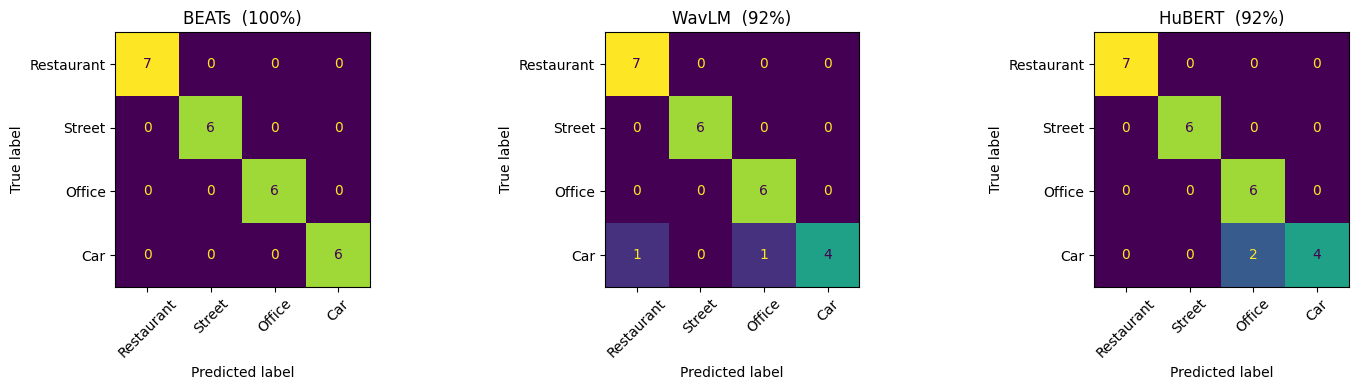

In [8]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

SCENE_NAMES = list(TARGET_SCENES)

# one shared train/test split (indices), reused for every model = fair comparison
idx_train, idx_test = train_test_split(
    np.arange(len(labels)), test_size=TEST_FRACTION, random_state=SEED, stratify=labels
)
y_train, y_test = labels[idx_train], labels[idx_test]

probes, accuracies, cv_scores = {}, {}, {}
for name, X in features.items():
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    clf.fit(X[idx_train], y_train)
    y_pred = clf.predict(X[idx_test])
    acc = accuracy_score(y_test, y_pred)

    # 5-fold cross-validation over ALL clips: a more reliable estimate than the
    # single 25-clip test split (which is small, so its accuracy is a bit noisy).
    cv = cross_val_score(
        make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
        X, labels, cv=5, scoring="accuracy",
    )

    probes[name], accuracies[name], cv_scores[name] = clf, acc, cv
    print(f"\n===== {name}  |  test acc = {acc:.1%}  |  5-fold CV = {cv.mean():.1%} +/- {cv.std():.1%} =====")
    print(classification_report(y_test, y_pred, labels=SCENE_NAMES, zero_division=0))

# confusion matrices side by side
fig, axes = plt.subplots(1, len(features), figsize=(5 * len(features), 4))
for ax, (name, clf) in zip(np.atleast_1d(axes), probes.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, clf.predict(features[name][idx_test]),
        labels=SCENE_NAMES, ax=ax, colorbar=False, xticks_rotation=45,
    )
    ax.set_title(f"{name}  ({accuracies[name]:.0%})")
plt.tight_layout(); plt.show()

## Step 8 — Which model won?

A bar chart comparing the three foundation models, ranked by **5-fold cross-validated accuracy**
(error bars = standard deviation across folds). CV is more trustworthy than the single small test
split, so we pick the `best` model from it.

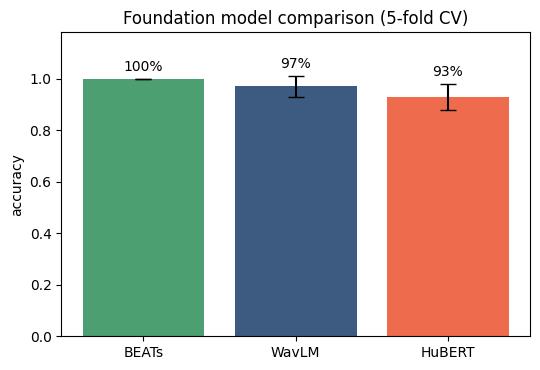

Best model: BEATs  |  CV 100.0% +/- 0.0%  |  held-out test 100.0%


In [9]:
# rank by cross-validated accuracy (more reliable than the single 25-clip split)
order = sorted(cv_scores, key=lambda m: cv_scores[m].mean(), reverse=True)

plt.figure(figsize=(5.5, 3.8))
bars = plt.bar(order, [cv_scores[m].mean() for m in order],
               yerr=[cv_scores[m].std() for m in order], capsize=6,
               color=["#4C9F70", "#3D5A80", "#EE6C4D"])
plt.ylim(0, 1.18); plt.ylabel("accuracy"); plt.title("Foundation model comparison (5-fold CV)")
for b, m in zip(bars, order):
    plt.text(b.get_x() + b.get_width() / 2, cv_scores[m].mean() + cv_scores[m].std() + 0.03,
             f"{cv_scores[m].mean():.0%}", ha="center")
plt.tight_layout(); plt.show()

best = order[0]
print(f"Best model: {best}  |  CV {cv_scores[best].mean():.1%} +/- {cv_scores[best].std():.1%}"
      f"  |  held-out test {accuracies[best]:.1%}")

## Step 9 — Classify a brand-new clip

Two things here: **(A)** a quick table of predictions on several held-out clips (instant, since it
reuses the cached embeddings), and **(B)** `predict_scene(path)`, which loads any audio file off disk,
embeds it with the chosen model, and returns the predicted scene with per-class probabilities. By
default it uses the `best` model from Step 8.

In [10]:
import pandas as pd

# A) quick scan of several held-out test clips -- instant, reuses cached embeddings
clf = probes[best]
rows = []
for j in idx_test[:8]:
    emb = features[best][int(j)].reshape(1, -1)
    pred = clf.predict(emb)[0]
    conf = clf.predict_proba(emb)[0].max()
    true = data.iloc[int(j)].label
    rows.append({"true scene": true, "predicted": pred,
                 "confidence": f"{conf:.0%}", "correct": "yes" if pred == true else "NO"})
print(f"Sample predictions on held-out clips (model: {best})")
display(pd.DataFrame(rows))


# B) classify a brand-new audio file from disk (loads the chosen model once)
def predict_scene(path, model_name=None):
    """Predict the acoustic scene of one audio file. Returns (label, {scene: probability})."""
    model_name = model_name or best
    model, embed = MODEL_BUILDERS[model_name]()
    emb = embed(load_audio(path)).reshape(1, -1)
    clf = probes[model_name]
    pred = clf.predict(emb)[0]
    proba = sorted(zip(clf.classes_, clf.predict_proba(emb)[0]), key=lambda kv: -kv[1])
    del model, embed; gc.collect()
    return pred, dict(proba)

demo_row = data.iloc[int(idx_test[0])]
pred, proba = predict_scene(demo_row.filepath)
print(f"\nSingle new-file demo  (model: {best})")
print(f"true scene : {demo_row.label}")
print(f"predicted  : {pred}")
print("confidence :", {k: f"{v:.1%}" for k, v in proba.items()})

Sample predictions on held-out clips (model: BEATs)


,true scene,predicted,confidence,correct
0,Restaurant,Restaurant,100%,yes
1,Street,Street,99%,yes
2,Restaurant,Restaurant,100%,yes
3,Office,Office,100%,yes
4,Car,Car,98%,yes
5,Car,Car,100%,yes
6,Restaurant,Restaurant,100%,yes
7,Restaurant,Restaurant,100%,yes



Single new-file demo  (model: BEATs)
true scene : Restaurant
predicted  : Restaurant
confidence : {'Restaurant': '99.8%', 'Office': '0.1%', 'Street': '0.1%', 'Car': '0.0%'}


## Recap & next steps

**What we did:** pulled three audio foundation models (BEATs, WavLM, HuBERT) from Hugging Face, used
them *frozen* to embed short clips, and trained a one-line logistic-regression probe to classify
`Restaurant / Street / Office / Car`.

**Ideas to improve accuracy:**
- Increase `N_PER_CLASS` (more training clips).
- Average several short windows per clip instead of one mean-pool.
- Try other checkpoints (e.g. `microsoft/wavlm-large`) or concatenate embeddings from all 3 models.
- Swap the logistic regression for a small MLP.
- For a real boost, *fine-tune* the backbone end-to-end.

**Reusing the trained probe:** the fitted classifiers live in `probes`; you can `joblib.dump` any of
them and load it later without recomputing embeddings.